In [1]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

# Create/Connect to the database file
conn = sqlite3.connect('fortress_bank.db')
cursor = conn.cursor()
print("Database connection established.")

Database connection established.


Creating the SQL Schema

In [2]:
# Define the tables
schema = """
CREATE TABLE IF NOT EXISTS Customers (
    CustomerID INTEGER PRIMARY KEY,
    FirstName TEXT,
    LastName TEXT,
    Email TEXT,
    KYC_Status TEXT
);

CREATE TABLE IF NOT EXISTS Accounts (
    AccountID INTEGER PRIMARY KEY,
    CustomerID INTEGER,
    AccountType TEXT,
    Balance DECIMAL(15,2),
    Status TEXT,
    FOREIGN KEY (CustomerID) REFERENCES Customers(CustomerID)
);

CREATE TABLE IF NOT EXISTS Transactions (
    TxnID INTEGER PRIMARY KEY,
    FromAccountID INTEGER,
    ToAccountID INTEGER,
    Amount DECIMAL(15,2),
    TxnType TEXT,
    Timestamp DATETIME,
    FOREIGN KEY (FromAccountID) REFERENCES Accounts(AccountID)
);
"""

# Execute the schema
cursor.executescript(schema)
conn.commit()
print("Database schema created successfully.")

Database schema created successfully.


Ingesting CSV Files

In [3]:
# Load your uploaded CSV files
customers_df = pd.read_csv('customers.csv')
accounts_df = pd.read_csv('accounts.csv')
transactions_df = pd.read_csv('transactions.csv')

# Push data to SQL
customers_df.to_sql('Customers', conn, if_exists='replace', index=False)
accounts_df.to_sql('Accounts', conn, if_exists='replace', index=False)
transactions_df.to_sql('Transactions', conn, if_exists='replace', index=False)

print("Data Ingestion Complete: CSVs are now SQL Tables.")

Data Ingestion Complete: CSVs are now SQL Tables.


In [9]:
print("Top 5 Customers:")
print(customers_df.head())
print("\n" + "="*50 + "\n")

print("Top 5 Accounts:")
print(accounts_df.head())
print("\n" + "="*50 + "\n")

print("Top 5 Transactions:")
print(transactions_df.head())

Top 5 Customers:
   CustomerID    FirstName    LastName                       Email KYC_Status
0           1  Christopher        Hill   joshuacarroll@example.net   Verified
1           2       Amanda       Horne     devintorres@example.org    Pending
2           3      Rebecca       Quinn          ngreer@example.com   Verified
3           4      Lindsay        Dean           sknox@example.net   Verified
4           5      Charles  Mclaughlin  jacquelinerose@example.com    Flagged


Top 5 Accounts:
   AccountID  CustomerID AccountType   Balance  Status
0       1001           1     Savings  39900.68  Active
1       1002           2     Savings  41740.90  Active
2       1003           3     Savings   1074.66  Active
3       1004           4    Business  29854.19  Active
4       1005           5    Business   3511.18  Active


Top 5 Transactions:
   TxnID  FromAccountID  ToAccountID    Amount   TxnType            Timestamp
0      1           1057         1006   7238.38  Transfer  2026-01-2

Implementing the "Velocity Check" (Fraud Detection)

In [4]:
# Query: Find accounts with high transaction frequency (Velocity Check)
velocity_query = """
SELECT FromAccountID, COUNT(TxnID) as TxnCount
FROM Transactions
GROUP BY FromAccountID
HAVING TxnCount > 5
ORDER BY TxnCount DESC;
"""

velocity_df = pd.read_sql_query(velocity_query, conn)
print("Accounts flagged for high-velocity activity:")
print(velocity_df)

Accounts flagged for high-velocity activity:
    FromAccountID  TxnCount
0            1037        11
1            1084        10
2            1080         9
3            1041         9
4            1008         9
5            1065         8
6            1052         8
7            1040         8
8            1038         8
9            1024         8
10           1015         8
11           1089         7
12           1087         7
13           1078         7
14           1077         7
15           1068         7
16           1062         7
17           1059         7
18           1058         7
19           1051         7
20           1050         7
21           1035         7
22           1029         7
23           1025         7
24           1021         7
25           1019         7
26           1017         7
27           1013         7
28           1009         7
29           1006         7
30           1001         7
31           1092         6
32           1086         6
33 

Visualizing Fraud Distribution

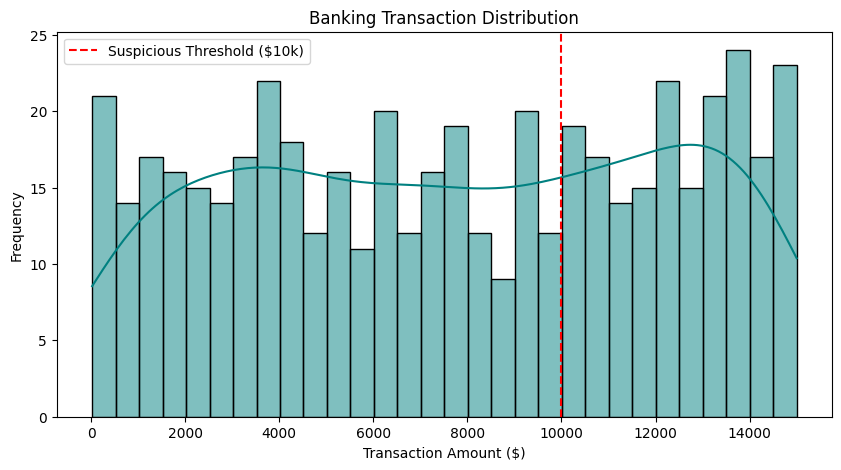

In [5]:
# Visualize the distribution of transaction amounts
plt.figure(figsize=(10, 5))
sns.histplot(transactions_df['Amount'], bins=30, color='teal', kde=True)
plt.axvline(10000, color='red', linestyle='--', label='Suspicious Threshold ($10k)')
plt.title('Banking Transaction Distribution')
plt.xlabel('Transaction Amount ($)')
plt.ylabel('Frequency')
plt.legend()
plt.show() # In .ipynb, this will display the plot directly below the cell

The Secure Transfer Function

In [6]:
def execute_secure_transfer(sender_account_id, receiver_account_id, amount):
    """
    Stepwise procedure to ensure ACID compliance:
    1. Atomicity: Both debit and credit happen, or neither happens.
    2. Consistency: Total money in the system remains the same.
    3. Isolation: This transaction doesn't interfere with others.
    4. Durability: Once committed, the data is saved permanently.
    """
    try:
        # Step 1: Start the transaction
        # This tells SQL to 'hold' changes in a temporary state
        cursor.execute("BEGIN TRANSACTION;")

        # Step 2: Validation - Check if sender has enough money
        # (Integrity check before modifying data)
        cursor.execute("SELECT Balance FROM Accounts WHERE AccountID = ?", (sender_account_id,))
        sender_balance = cursor.fetchone()[0]

        if sender_balance < amount:
            print(f"Transaction Aborted: Account {sender_account_id} has insufficient funds.")
            conn.rollback() # Cancel any temporary changes
            return

        # Step 3: Debit the Sender
        # Decreasing the balance of the person sending money
        cursor.execute("UPDATE Accounts SET Balance = Balance - ? WHERE AccountID = ?", 
                       (amount, sender_account_id))

        # Step 4: Credit the Receiver
        # Increasing the balance of the person receiving money
        cursor.execute("UPDATE Accounts SET Balance = Balance + ? WHERE AccountID = ?", 
                       (amount, receiver_account_id))

        # Step 5: Log the record in Transactions table
        # Maintaining the audit trail for data integrity
        cursor.execute("""
            INSERT INTO Transactions (FromAccountID, ToAccountID, Amount, TxnType, Timestamp)
            VALUES (?, ?, ?, 'Transfer', datetime('now'))
        """, (sender_account_id, receiver_account_id, amount))

        # Step 6: Commit the changes
        # Only now do the changes become permanent in the database
        conn.commit()
        print(f"Successfully transferred ${amount} from {sender_account_id} to {receiver_account_id}.")

    except Exception as e:
        # Step 7: Rollback on Error
        # If there is a system crash or SQL error, undo everything to the start point
        conn.rollback()
        print(f"Critical System Error: {e}. All changes have been rolled back to maintain integrity.")

Testing the Engine (Success Case)

In [7]:
# Test a valid transfer
execute_secure_transfer(1001, 1002, 500.00)

# Verify the balances updated correctly
result = pd.read_sql_query("SELECT AccountID, Balance FROM Accounts WHERE AccountID IN (1001, 1002)", conn)
print(result)

Successfully transferred $500.0 from 1001 to 1002.
   AccountID   Balance
0       1001  39400.68
1       1002  42240.90


Testing the Engine (Failure Case)

In [8]:
# Test an invalid transfer (Assuming balance is less than 1 million)
execute_secure_transfer(1001, 1002, 1000000.00)

Transaction Aborted: Account 1001 has insufficient funds.
